BA Algorithm

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
def barabasi_albert_manual(n, m0, m):
    """
    n  = total nodes
    m0 = initial fully connected nodes
    m  = edges added per new node
    """

    G = nx.Graph()

    # Step 1: Create initial complete graph
    for i in range(m0):
        for j in range(i+1, m0):
            G.add_edge(i, j)

    # Step 2: Add new nodes with preferential attachment
    for new_node in range(m0, n):
        degrees = np.array([G.degree(node) for node in G.nodes()])
        total_degree = degrees.sum()

        # Probability distribution
        probs = degrees / total_degree

        existing_nodes = list(G.nodes())

        # Choose m unique nodes based on degree probability
        targets = set()
        while len(targets) < m:
            chosen = np.random.choice(existing_nodes, p=probs)
            targets.add(chosen)

        for t in targets:
            G.add_edge(new_node, t)

    return G

n = 200     # >=100 (important for marks)
m0 = 5
m = 3

G = barabasi_albert_manual(n, m0, m)

(a) Average Clustering Coefficient

In [4]:
C = nx.average_clustering(G)
print("Average Clustering Coefficient:", C)

Average Clustering Coefficient: 0.12213360326560734


(b) Characteristic Path Length

In [5]:
if nx.is_connected(G):
    L = nx.average_shortest_path_length(G)
else:
    Gcc = G.subgraph(max(nx.connected_components(G), key=len))
    L = nx.average_shortest_path_length(Gcc)

print("Characteristic Path Length:", L)

Characteristic Path Length: 2.815577889447236


(c) Degree Distribution

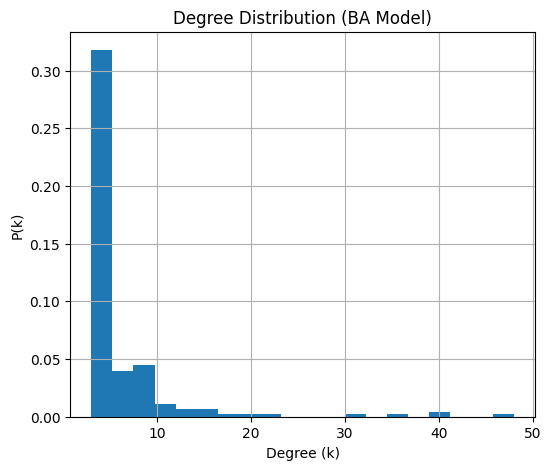

In [6]:
degrees = [G.degree(n) for n in G.nodes()]

plt.figure(figsize=(6,5))
plt.hist(degrees, bins=20, density=True)
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (BA Model)")
plt.grid(True)
plt.show()

Log-Log Plot

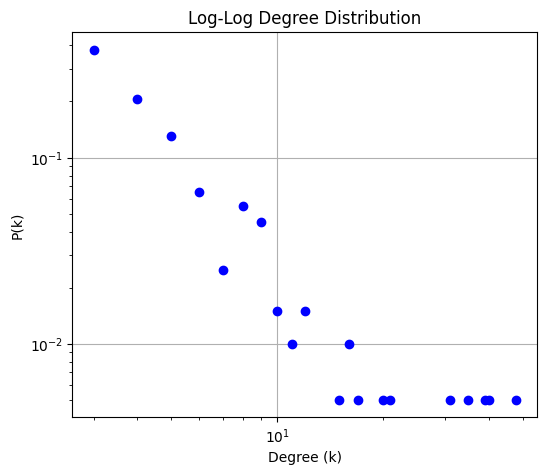

In [7]:
unique_deg, counts = np.unique(degrees, return_counts=True)
prob = counts / sum(counts)

plt.figure(figsize=(6,5))
plt.loglog(unique_deg, prob, 'bo')
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Log-Log Degree Distribution")
plt.grid(True)
plt.show()